# Real-Time Human Activity Recognition — HW4 (Display notebook)

**Almog Tal · Daniel Korkevados · Lior Sulshtein · Ilay Damari**
Introduction to Data Science in Industry — Final Project (HW4)

This notebook is the companion to the presentation. **This notebook is already executed** — every figure and result is visible below. During the talk we simply *scroll to* the section the current slide points to.

### Presentation ↔ notebook map
| Slide | Notebook section |
|------|------------------|
| Data overview | **1. Data** |
| EDA takeaways | **2. Exploratory Data Analysis** |
| Modeling approach | **3. Models** |
| Test protocol | **4. How we evaluate** |
| Results / confusion / ablations | **5. Results** |
| Final model 94.8% | **6. Inference demo** |
| Evaluation vs criteria | **7. Evaluation** |
| Deployment | **8. Deployment** |

## Setup

In [1]:
%matplotlib inline
import json, time, inspect, warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image
import har_utils as hu          # data loading + constants (readable helper module)
import har_plots as hp          # all plotting functions (readable helper module)
hp.set_style(); warnings.filterwarnings("ignore")
print("UCI HAR dataset:", hu.find_uci_dir())

UCI HAR dataset: /Users/korki/BGU/Year_D/סמסטר ח/מבוא לדאטה סייננס בתעשייה/Project_final/DS-HER/Data/human+activity+recognition+using+smartphones


## 1. Data — UCI HAR, split by subject

30 volunteers wore a waist smartphone; the inertial stream (accelerometer +
gyroscope, **9 channels**) is cut into **2.56 s windows of 128 samples** at 50 Hz
and labelled with one of **six activities**. The train/test split is
**subject-disjoint** (21 train / 9 test) so scores measure generalisation to
*new people*, not memorisation.

In [2]:
Xtr, ytr, subj_tr = hu.load_raw_windows("train")   # raw signal windows (N,128,9)
Xte, yte, subj_te = hu.load_raw_windows("test")
print(f"train windows {Xtr.shape},  test windows {Xte.shape}")
print(f"train subjects {sorted(set(subj_tr))}")
print(f"test  subjects {sorted(set(subj_te))}   <- never seen in training")
print(f"activities: {hu.ACTIVITIES}")

train windows (7352, 128, 9),  test windows (2947, 128, 9)
train subjects [1, 3, 5, 6, 7, 8, 11, 14, 15, 16, 17, 19, 21, 22, 23, 25, 26, 27, 28, 29, 30]
test  subjects [2, 4, 9, 10, 12, 13, 18, 20, 24]   <- never seen in training
activities: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


*One labelled window = 128 timesteps × 9 sensor channels (2.56 s).*

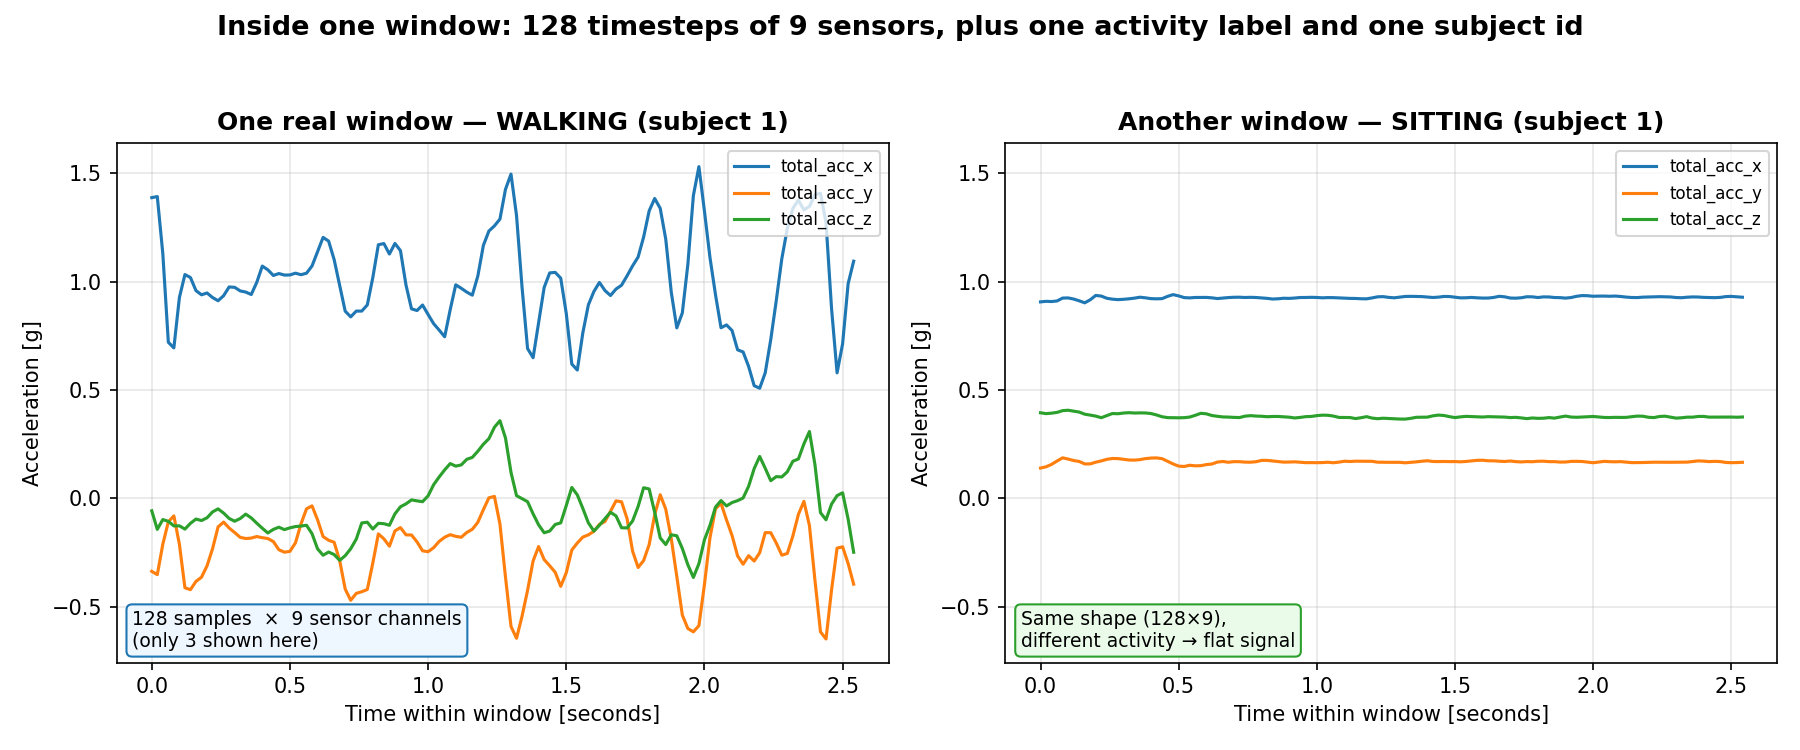

In [3]:
Image("../assets/concept_one_window.png")

## 2. Exploratory Data Analysis

A strong EDA drives every later choice. Below: class balance, per-subject
coverage, what raw windows look like, how motion energy and **gravity direction**
separate the activities, the **frequency signatures** that motivate Fourier
features, channel correlations, and a 2-D PCA view.

***Class balance** — six activities, ratio ≈1.4:1 (no severe imbalance).*

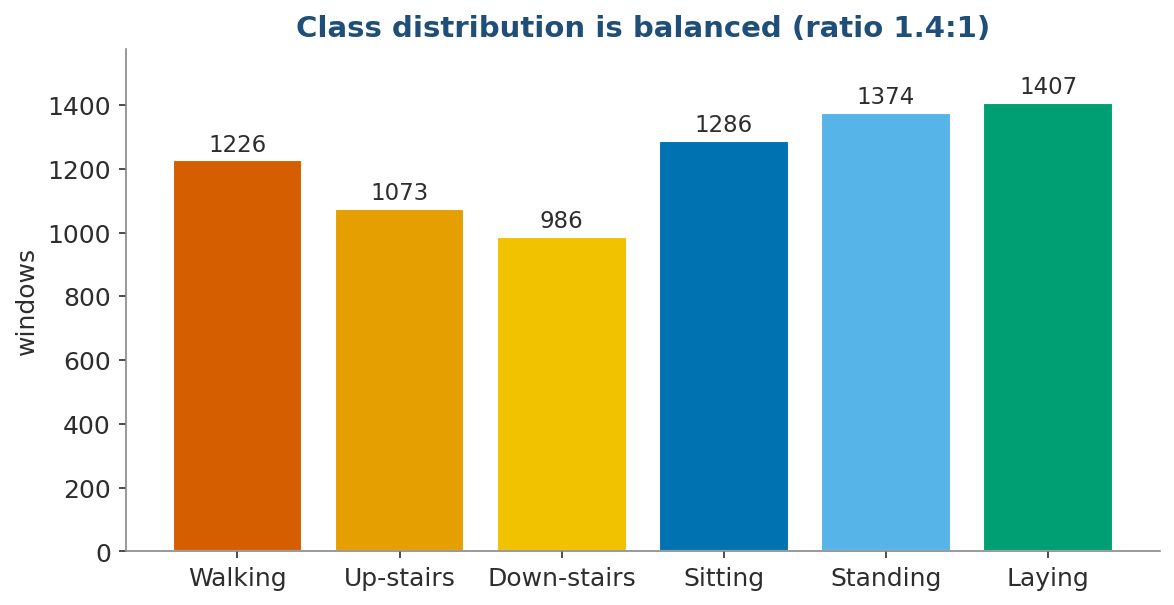

In [4]:
Image("../assets/eda_class_distribution.png")

***Per-subject coverage** — every subject performs all six activities.*

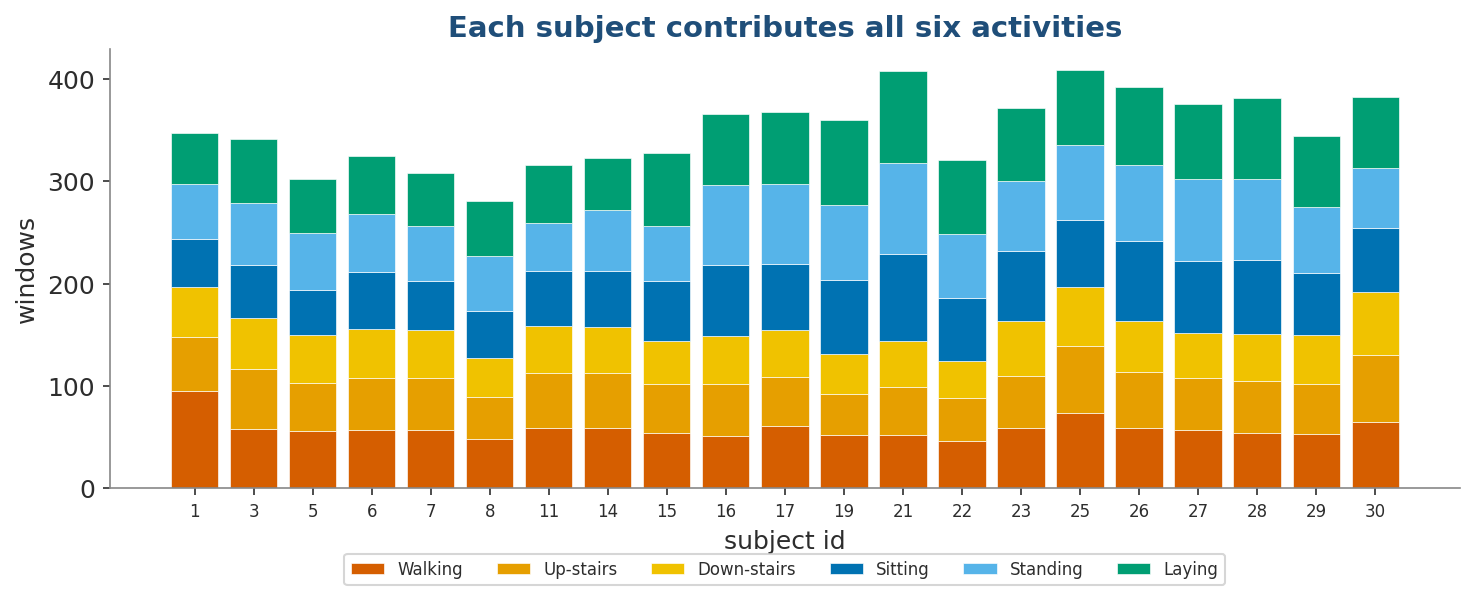

In [5]:
Image("../assets/eda_windows_per_subject.png")

***Raw walking window** — strong oscillations on all axes.*

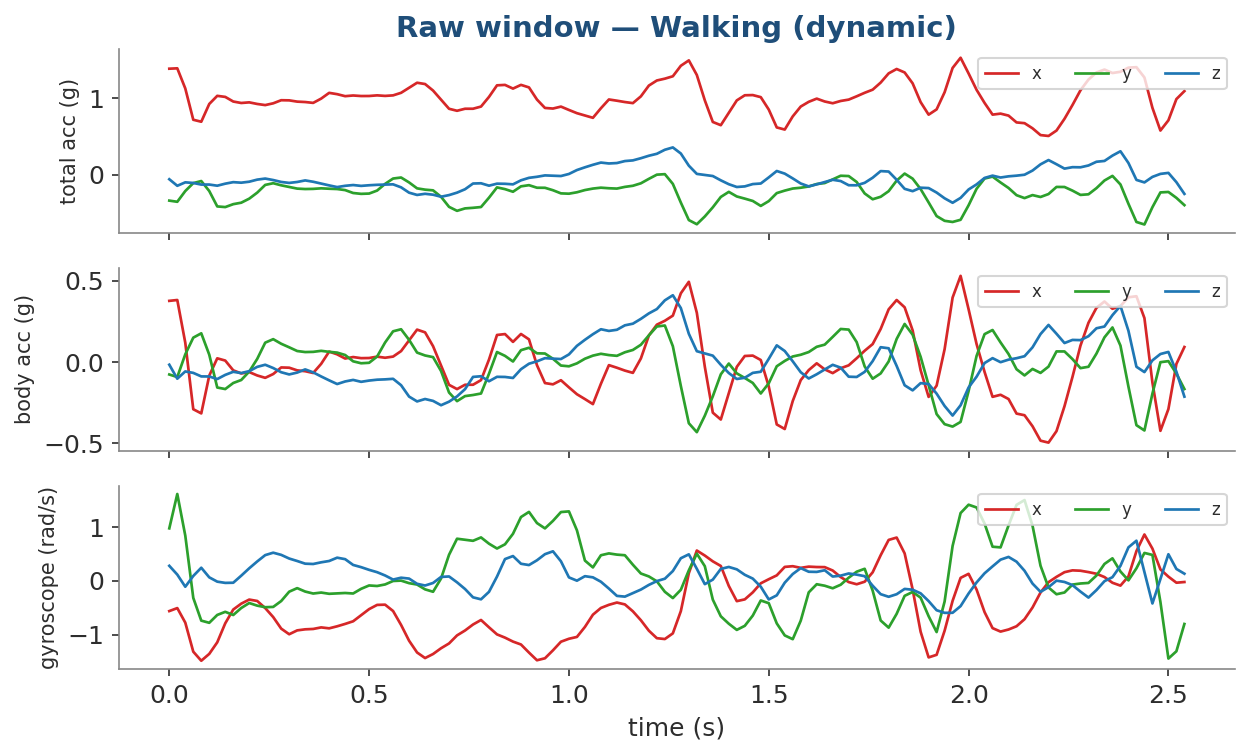

In [6]:
Image("../assets/eda_raw_walking.png")

***Raw laying window** — almost flat; only the gravity offset differs.*

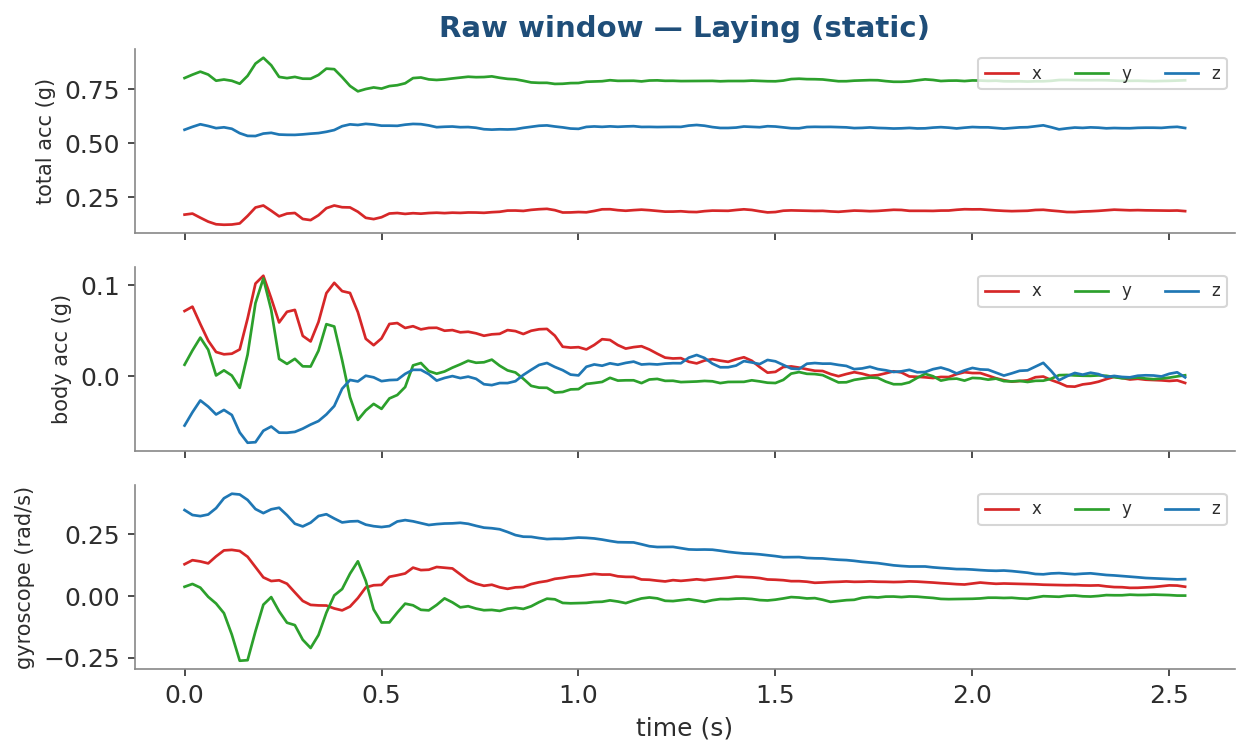

In [7]:
Image("../assets/eda_raw_laying.png")

***Motion energy** cleanly splits dynamic vs static activities.*

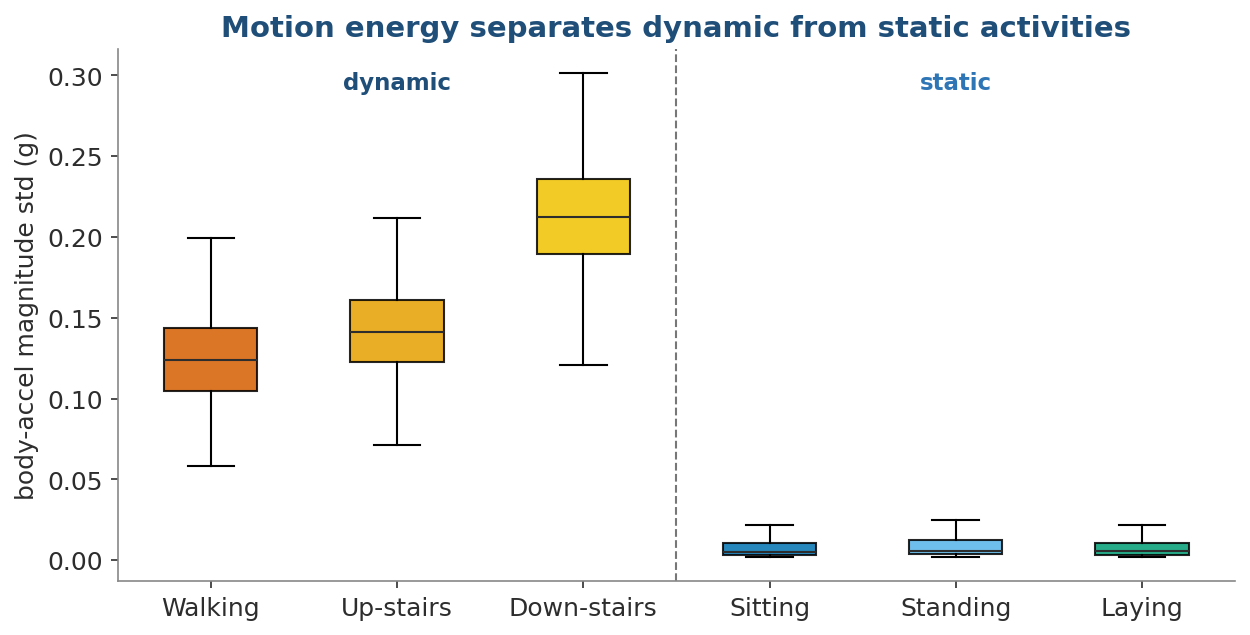

In [8]:
Image("../assets/eda_dynamic_vs_static.png")

***Gravity direction** separates sitting / standing / laying postures.*

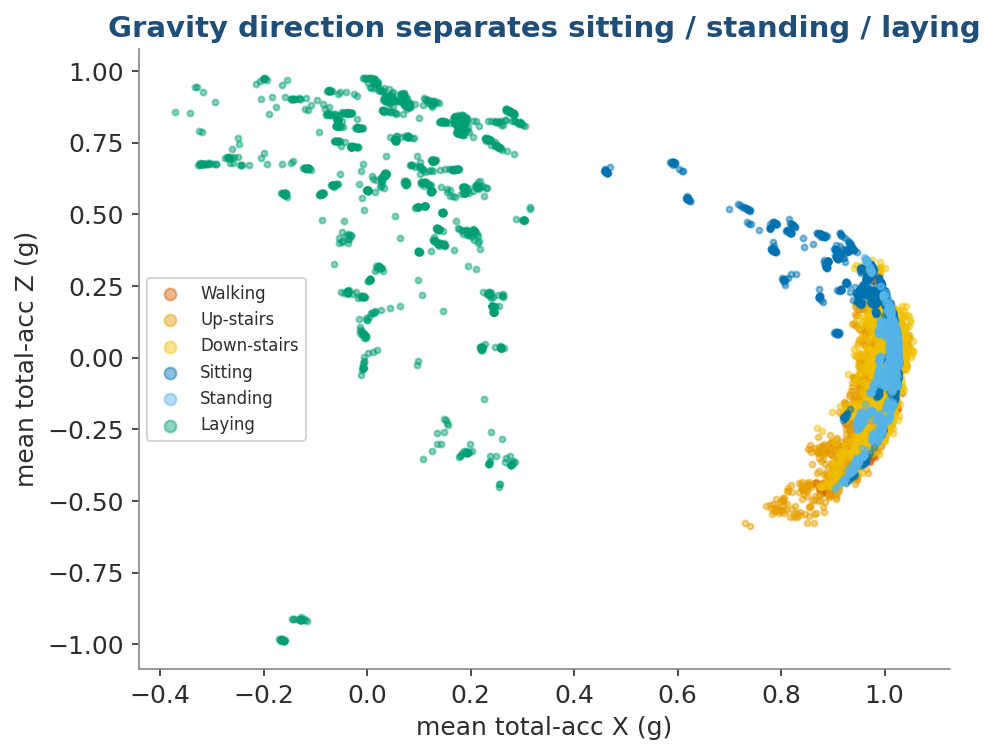

In [9]:
Image("../assets/eda_gravity_orientation.png")

***Frequency signatures** — walking has a sharp ~1.6 Hz gait peak; static is near-DC.*

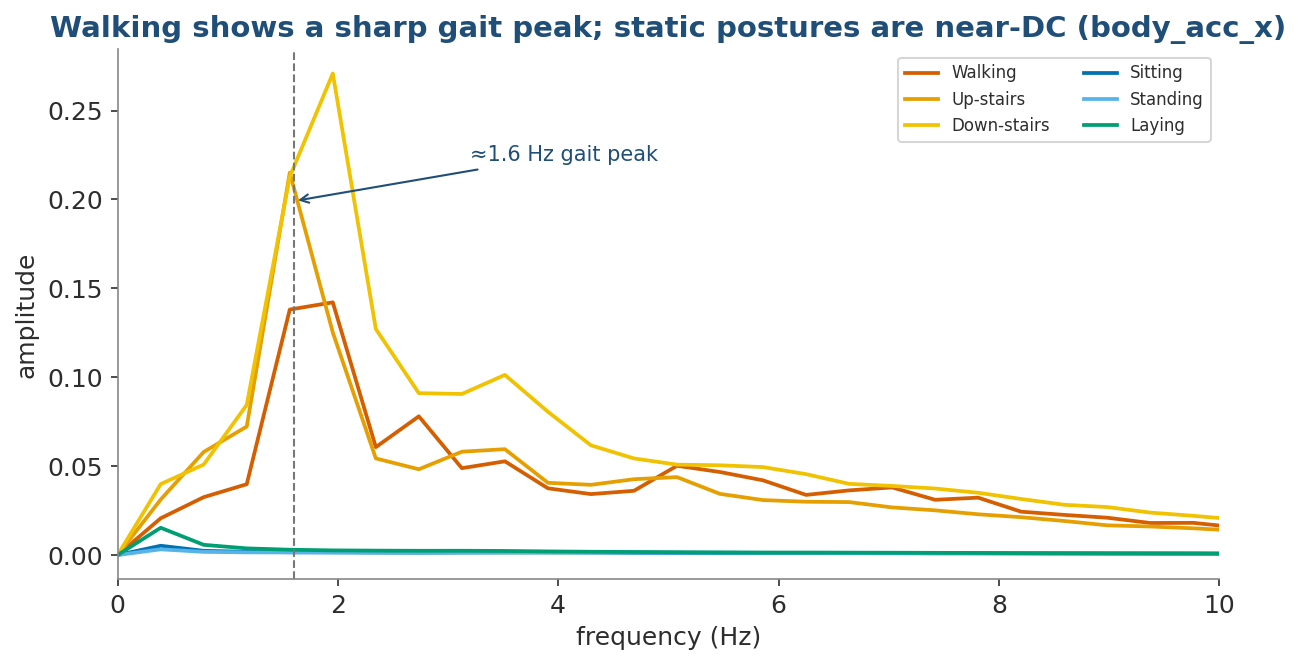

In [10]:
Image("../assets/eda_fft_spectra.png")

***Dominant frequency** per window confirms the gait-cadence clustering.*

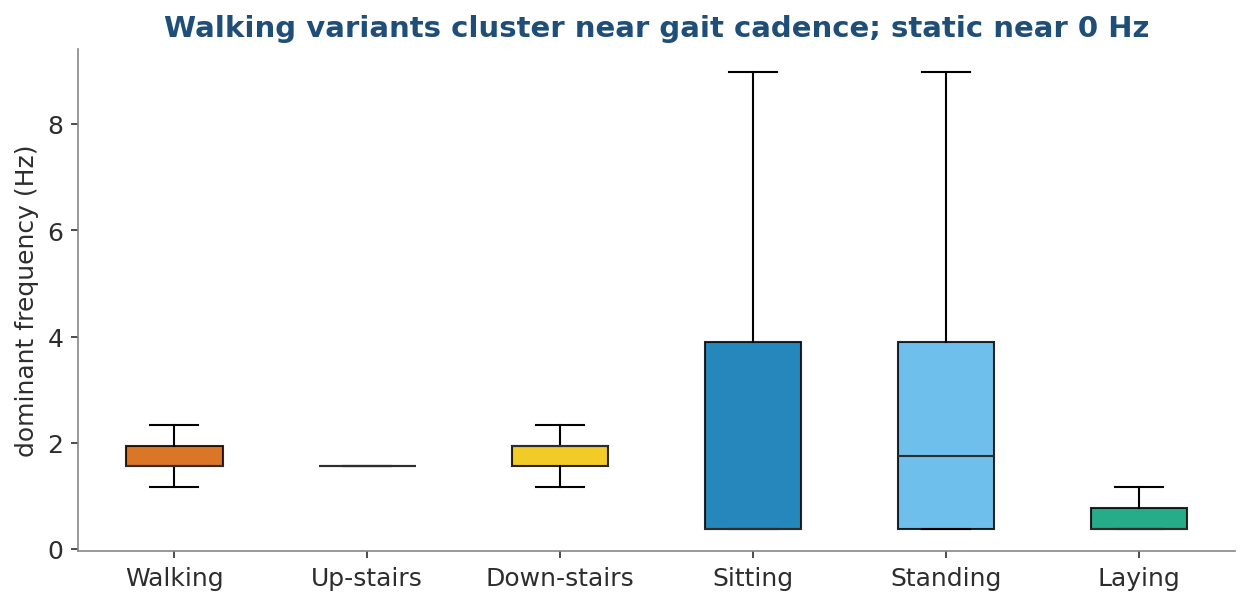

In [11]:
Image("../assets/eda_dominant_freq.png")

***Channel correlation** — total/body acceleration axes are strongly related.*

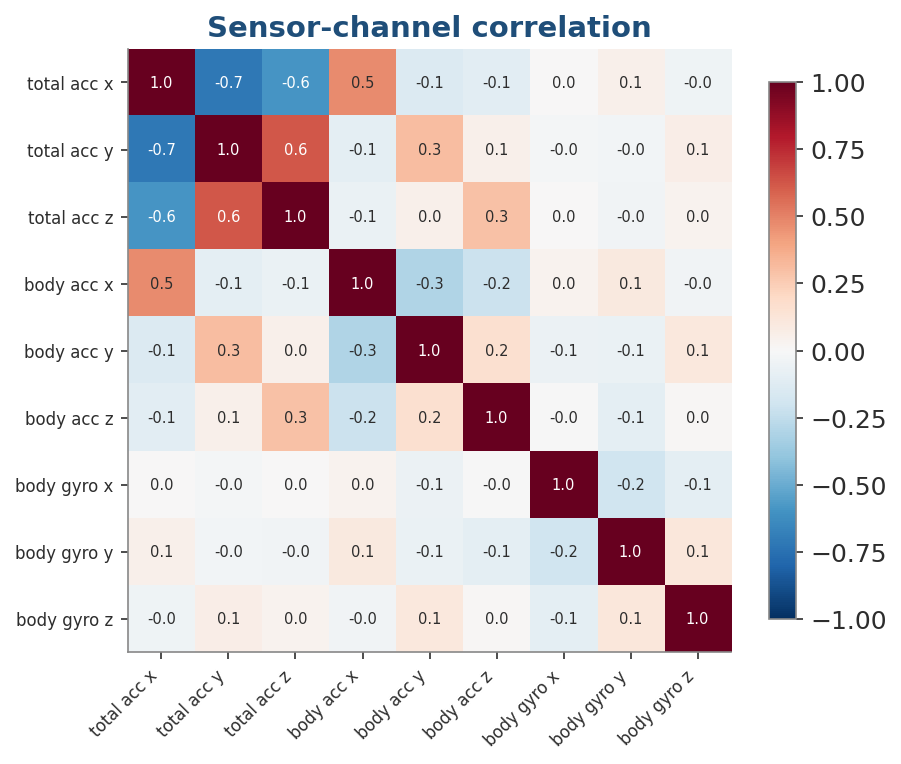

In [12]:
Image("../assets/eda_channel_correlation.png")

***2-D PCA** — activities already form clear clusters before any model.*

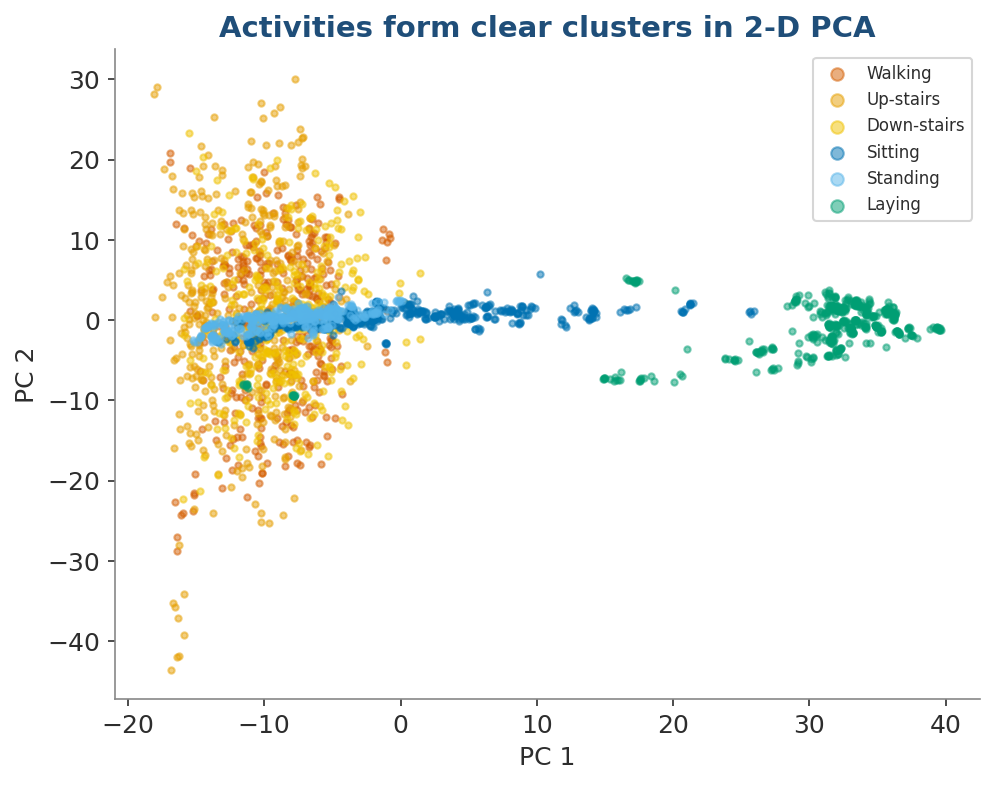

In [13]:
Image("../assets/eda_pca_2d.png")

## 3. Models — three views of the same window

| Representation | Models |
|----------------|--------|
| 6 engineered features | Logistic Regression, Random Forest (weak baselines) |
| 165 Fourier features | LogReg / SVM / RF (classical, frequency domain) |
| **Raw 128×9 signal** | Main / Patch / CNN Transformer, **Fourier+Transformer** |

Our flagship is the **Fourier+Transformer**: a dual-branch encoder that attends
over the *time* signal and over its *FFT magnitude*, then fuses both. Here is the
actual architecture (the same code that produced the deployed checkpoint):

In [14]:
from fourier_transformer import FourierTransformer
print(inspect.getsource(FourierTransformer))

class FourierTransformer(nn.Module):
    """Dual-branch transformer: self-attention over TIME tokens and over FFT tokens."""
    def __init__(self, in_ch=9, seq_len=128, num_classes=6,
                 d_model=64, nhead=4, num_layers=2, dim_ff=128, dropout=0.15):
        super().__init__()
        n_freq = seq_len // 2 + 1
        k = torch.arange(n_freq).unsqueeze(1).float()
        n = torch.arange(seq_len).unsqueeze(0).float()
        ang = 2.0 * math.pi * k * n / seq_len
        self.register_buffer("dft_cos", torch.cos(ang))
        self.register_buffer("dft_sin", torch.sin(ang))

        self.time_proj = nn.Linear(in_ch, d_model)
        self.time_cls = nn.Parameter(torch.zeros(1, 1, d_model)); nn.init.trunc_normal_(self.time_cls, std=0.02)
        self.time_pe = SinusoidalPE(d_model, max_len=seq_len + 1)
        self.time_blocks = nn.ModuleList([EncoderBlock(d_model, nhead, dim_ff, dropout) for _ in range(num_layers)])

        self.freq_proj = nn.Linear(in_ch, d_model)
        

*Each window feeds the classical feature models and the raw-signal transformers.*

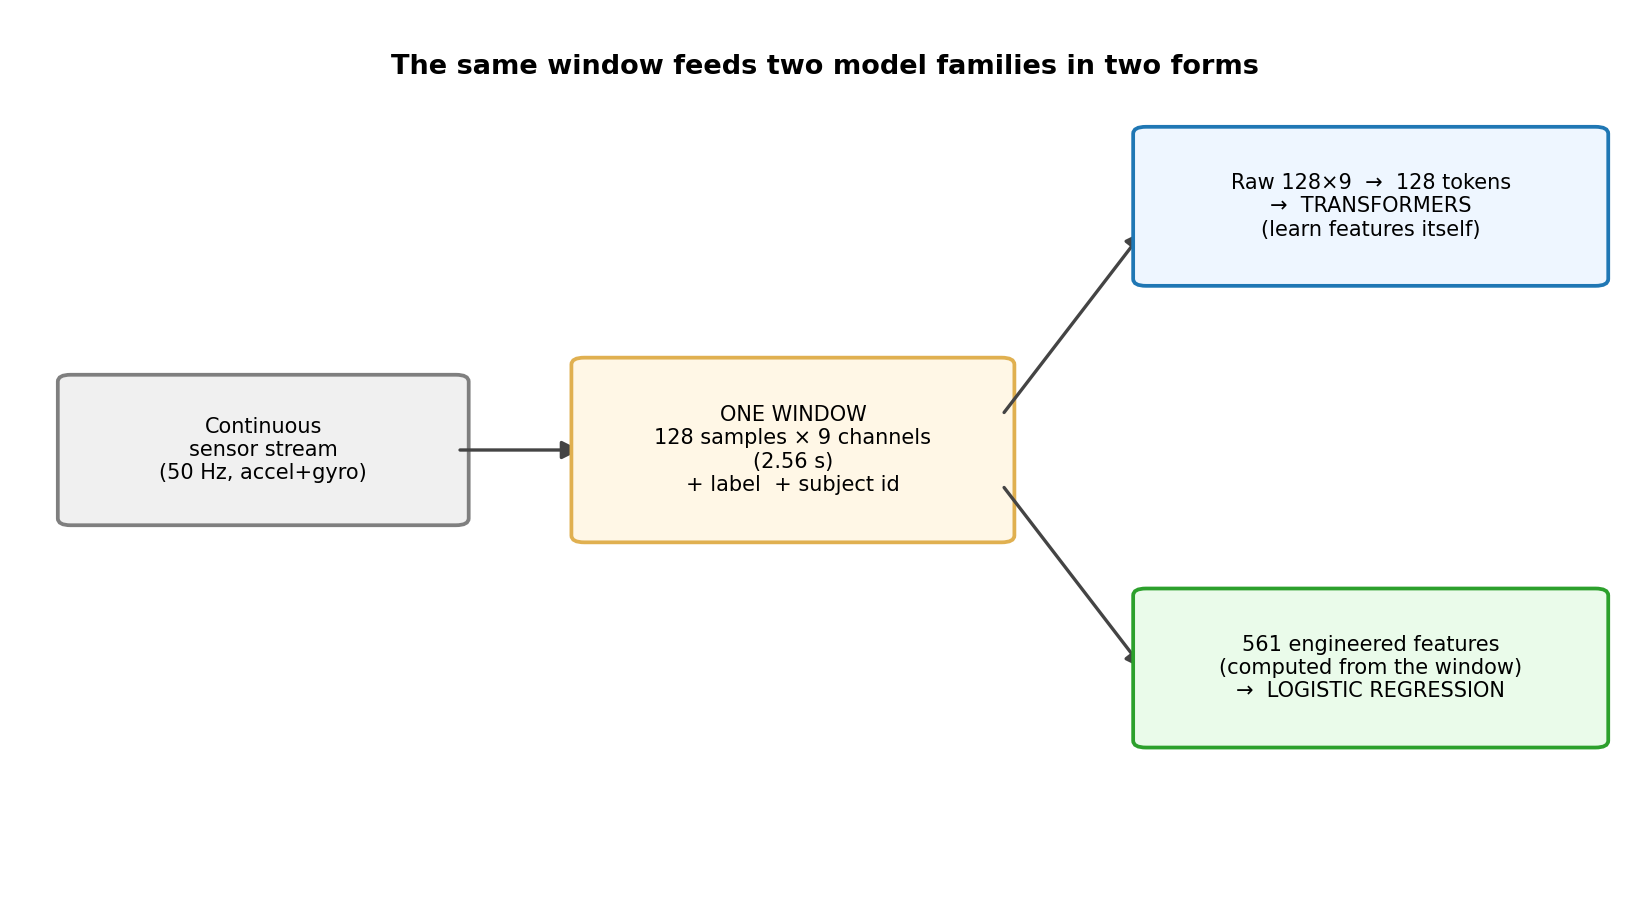

In [15]:
Image("../assets/concept_window_to_models.png")

## 4. How we evaluate

* **Subject-disjoint split** — the 9 test subjects never appear in training.
* **Macro-F1** — weights all six classes equally (no majority-class bias).
* **Test set used once** — the official UCI test split, scored a single time.

## 5. Results

We score the **deployed Fourier+Transformer** live on the 2,947 unseen test
windows, then look at the confusion structure, the model comparison, and the
ablations.

In [16]:
from fourier_transformer import load_model, predict
from sklearn.metrics import accuracy_score, f1_score, classification_report

model, meta = load_model("artifacts/fourier_transformer_best.pt",
                         "artifacts/model_meta.json", device="cpu")
t0 = time.time()
y_pred, names, probs = predict(model, Xte, meta, device="cpu")
acc = accuracy_score(yte, y_pred); f1 = f1_score(yte, y_pred, average="macro")
print(f"Deployed Fourier+Transformer on {len(Xte)} unseen windows "
      f"({time.time()-t0:.2f}s, CPU)")
print(f"  test accuracy = {acc:.4f}   macro-F1 = {f1:.4f}")
print()
print(classification_report(yte, y_pred, target_names=hu.ACTIVITY_SHORT, digits=3))

Deployed Fourier+Transformer on 2947 unseen windows (0.50s, CPU)
  test accuracy = 0.9484   macro-F1 = 0.9477

              precision    recall  f1-score   support

     Walking      0.975     0.950     0.962       496
   Up-stairs      0.986     0.913     0.948       471
 Down-stairs      0.889     0.995     0.939       420
     Sitting      0.945     0.880     0.911       491
    Standing      0.904     0.953     0.928       532
      Laying      0.994     1.000     0.997       537

    accuracy                          0.948      2947
   macro avg      0.949     0.948     0.948      2947
weighted avg      0.950     0.948     0.948      2947



**Note:** the headline checkpoint was trained with light data augmentation, reaching **94.8%**; the same-run comparison below (without augmentation) put the Fourier+Transformer at 90.2% — still the best raw-signal model.

***Confusion matrix** — perfect dynamic/static separation; the only real confusion is sitting ↔ standing (boxed).*

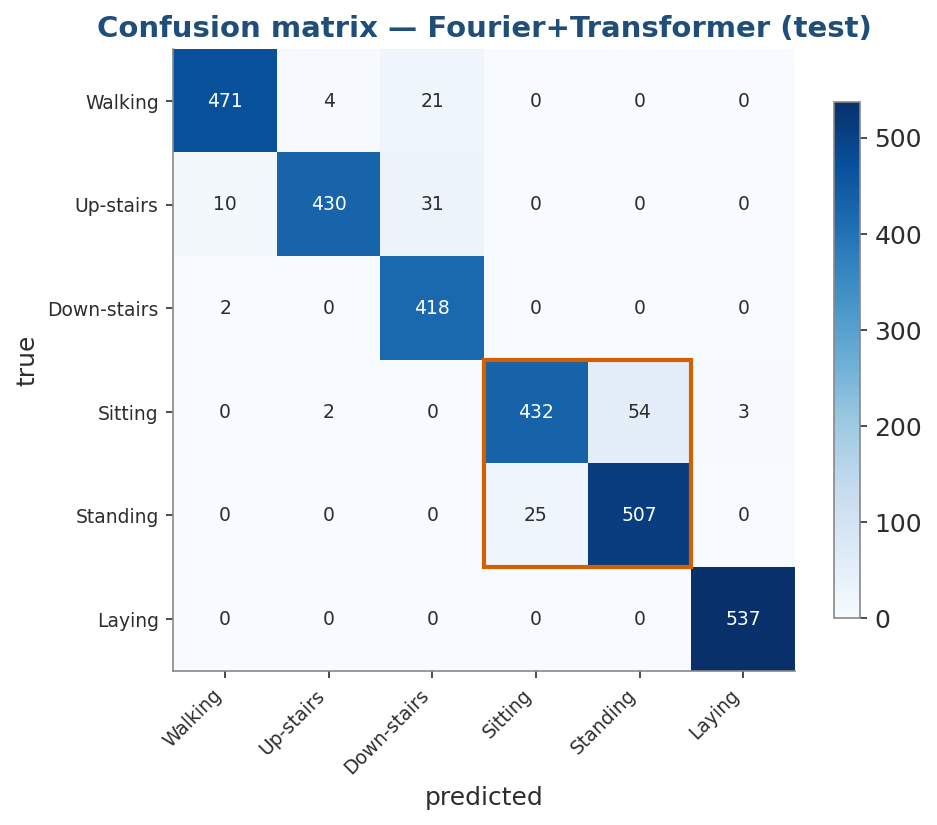

In [17]:
Image("../assets/results_confusion_fourier.png")

***Model comparison** — Fourier+Transformer leads the raw-signal models; engineered-feature baselines (dashed) remain competitive.*

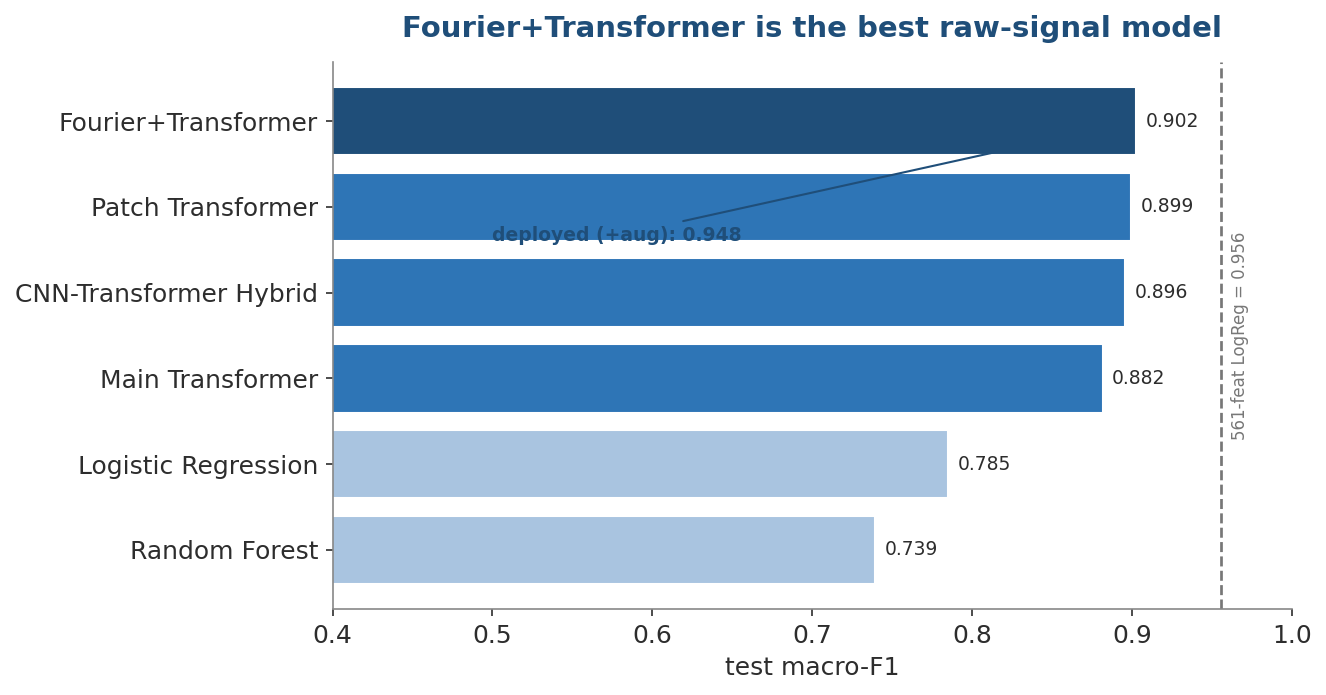

In [18]:
Image("../assets/results_model_comparison.png")

***Architecture ablation** — positional encoding + patch-8 give the biggest lift.*

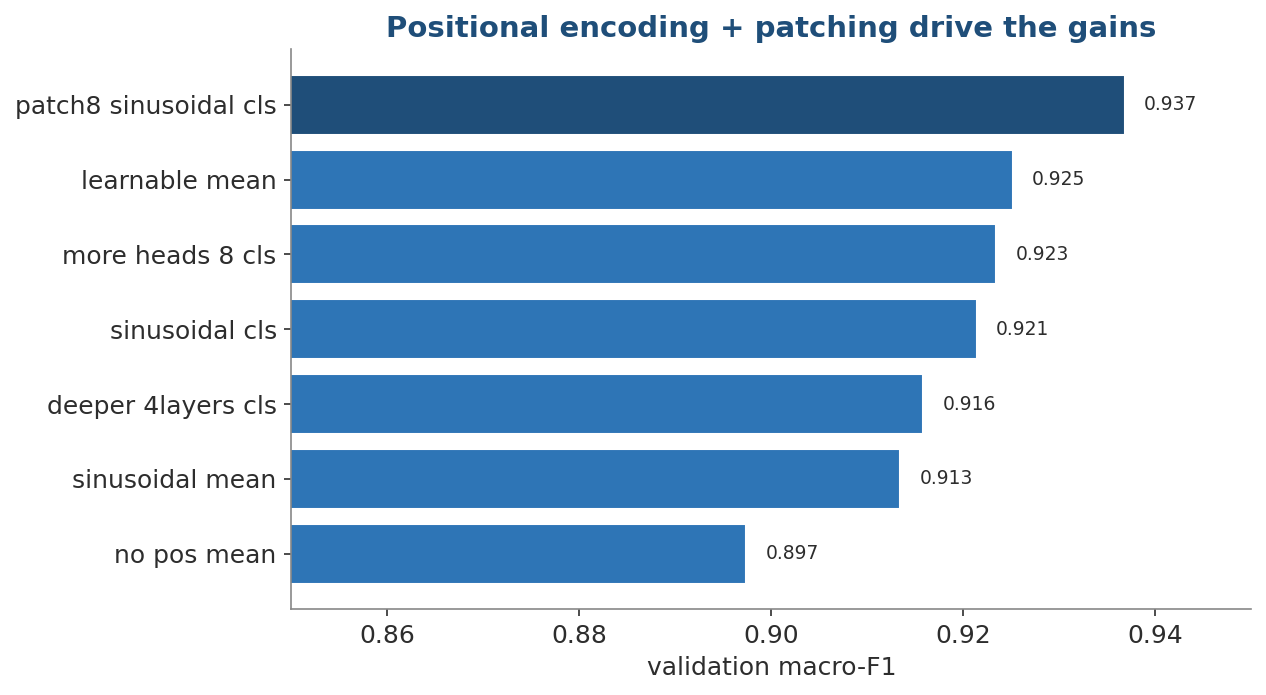

In [19]:
Image("../assets/results_architecture_ablation.png")

***Sensor ablation** — acceleration carries the signal; gyroscope alone is near-chance.*

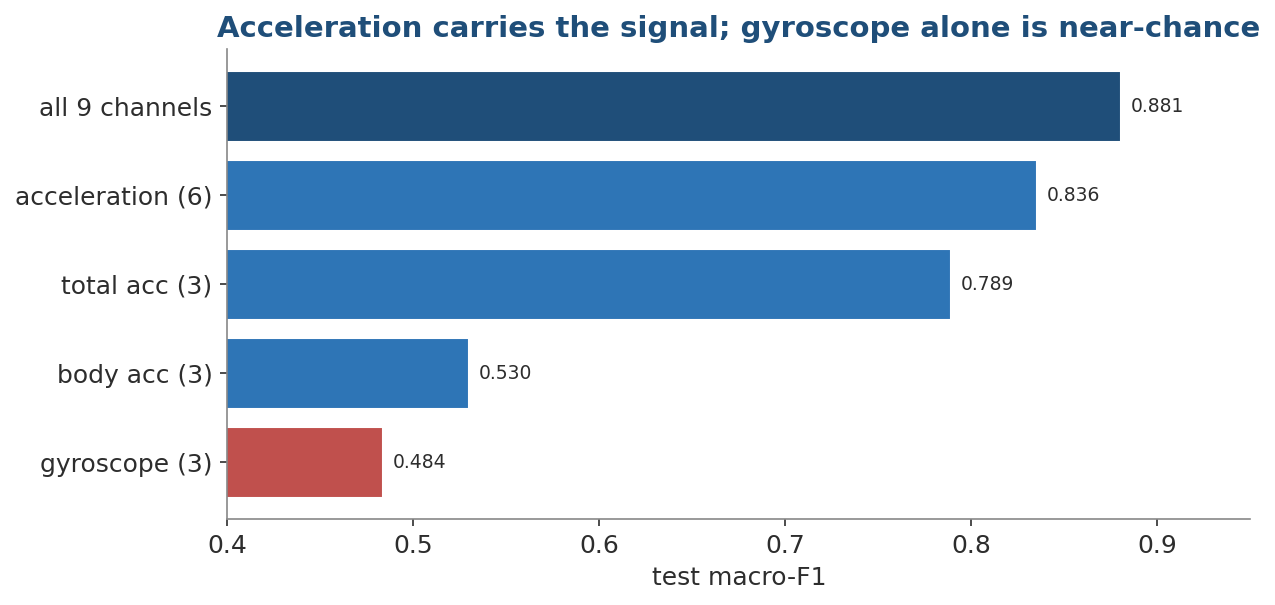

In [20]:
Image("../assets/results_sensor_ablation.png")

## 6. Inference demo — what runs in real time

A single 2.56 s window classifies in a few milliseconds on CPU — fast enough to
update the live prediction several times per second. Here are a few individual
windows with the model's confidence:

In [21]:
rng = np.random.default_rng(0)
for i in rng.choice(len(Xte), size=6, replace=False):
    p = probs[i]; k = int(p.argmax())
    mark = "✓" if k == yte[i] else "✗"
    print(f"{mark}  true={hu.ACTIVITIES[yte[i]]:18s} "
          f"pred={hu.ACTIVITIES[k]:18s} conf={p[k]:.2f}")

✗  true=SITTING            pred=LAYING             conf=0.68
✓  true=STANDING           pred=STANDING           conf=0.72
✓  true=WALKING_UPSTAIRS   pred=WALKING_UPSTAIRS   conf=0.92
✓  true=WALKING_DOWNSTAIRS pred=WALKING_DOWNSTAIRS conf=1.00
✓  true=WALKING_DOWNSTAIRS pred=WALKING_DOWNSTAIRS conf=1.00
✓  true=WALKING            pred=WALKING            conf=1.00


> The closing **live demo** streams this same model from a phone in real time — see `live_demo_app/` (run it after the slides).

## 7. Evaluation vs the business success criteria

| HW1 success criterion | Status |
|---|---|
| Working pipeline raw sensors → activity label | ✅ end-to-end, runs on CPU |
| Standard metrics on a train/test split | ✅ accuracy, P/R/F1, confusion matrix |
| Separate the main activities (walk/sit/stand/lie) | ✅ 0 % dynamic↔static error |
| Discuss limitations (UCI vs live phone) | ✅ orientation & sampling shift documented |
| Reproducible, readable code | ✅ helper modules + fixed seed |

**Main limitation:** sitting ↔ standing (both near-DC) and a few hard subjects
drive most of the remaining error.

## 8. Deployment — real-time service

*Phone stream → 2.56 s window → z-score → Fourier+Transformer → activity label.*

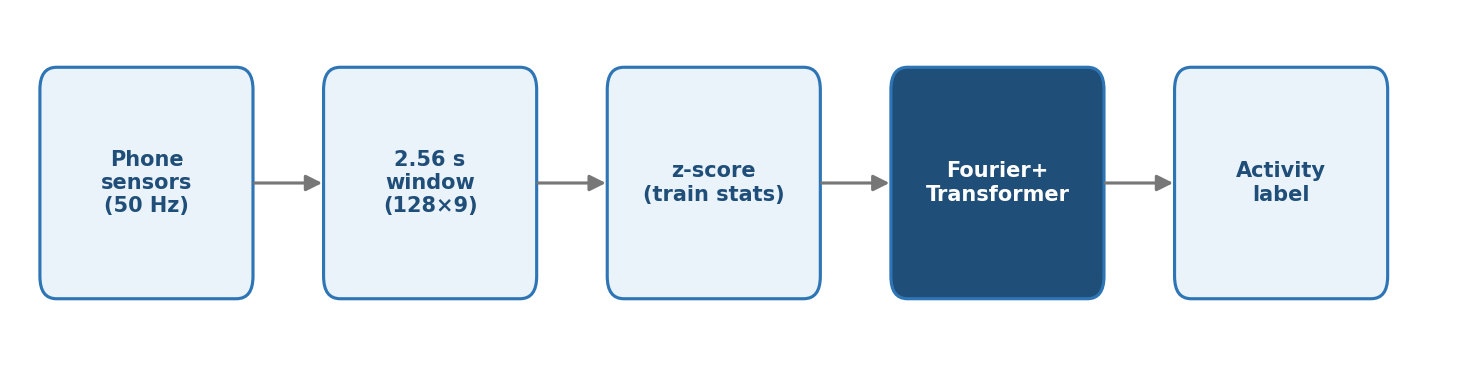

In [22]:
Image("../assets/deploy_pipeline.png")

The trained checkpoint is wrapped in a small Flask service (`live_demo_app/`)
that takes a live phone sensor stream and shows the predicted activity in the
browser — the closing **live demo** of the talk.